In [1]:
import sys
import os
sys.path.append(os.pardir)

In [2]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

In [3]:
import matplotlib.pyplot as plt

In [4]:
#Modeling and Forecasting
import skforecast
import lightgbm
import sklearn
from lightgbm import LGBMRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import RFECV
from skforecast.recursive import ForecasterEquivalentDate, ForecasterRecursive
from skforecast.direct import ForecasterDirect
from skforecast.model_selection import TimeSeriesFold, bayesian_search_forecaster, backtesting_forecaster
from skforecast.feature_selection import select_features
from skforecast.preprocessing import RollingFeatures
from skforecast.plot import calculate_lag_autocorrelation, plot_residuals
from skforecast.metrics import calculate_coverage

/Users/maxwellgriffith/miniconda3/envs/loadcast/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import warnings
warnings.filterwarnings('once')

In [6]:
df = (pd.read_csv("../data/raw/loadtempday_clean.csv")
        .drop_duplicates()
        .pipe(lambda df: df.set_index(pd.to_datetime(df["date"])))
        .drop(columns = ["date"])
     )
#this will throw an error if there are duplicates
df.index = df.index.tz_localize(None)
df.index.freq = 'h'

In [7]:
df.head()

,Demand,Temperature,is_day
date,,,
2023-01-01 00:00:00,28291.0,11.3615,0
2023-01-01 01:00:00,28727.0,9.5615,0
2023-01-01 02:00:00,28370.0,7.9615,0
2023-01-01 03:00:00,27955.0,7.3115,0
2023-01-01 04:00:00,27668.0,6.2615,0


In [8]:
### Train Val Test Split
TRAIN_START = "2023-01-01 00:00:00"
TRAIN_END   = "2024-06-30 23:00:00"
VAL_START   = "2024-07-01 00:00:00"
VAL_END     = "2024-12-31 23:00:00"
TEST_START  = "2025-01-01 00:00:00"
TEST_END    = "2025-12-31 23:00:00"

In [9]:
data = df.copy()
data_train = data.loc[: TRAIN_END, :].copy()
data_val   = data.loc[VAL_START:VAL_END, :].copy()
data_test  = data.loc[TEST_START:, :].copy()

print(f"Train dates      : {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})")
print(f"Validation dates : {data_val.index.min()} --- {data_val.index.max()}  (n={len(data_val)})")
print(f"Test dates       : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})")

Train dates      : 2023-01-01 00:00:00 --- 2024-06-30 23:00:00  (n=13128)
Validation dates : 2024-07-01 00:00:00 --- 2024-12-31 23:00:00  (n=4416)
Test dates       : 2025-01-01 00:00:00 --- 2025-12-31 23:00:00  (n=8760)


### Baseline Forecaster
- seasonal naive forecaster used to compare performance of future models
- trained and evaluated with backtesting
- predicts each hour using the value of the same hour on the previous day

In [10]:
# Create baseline: value of the same hour of the previous day
forecaster = ForecasterEquivalentDate(
                 offset    = pd.DateOffset(days=1),
                 n_offsets = 1
             )

# Train forecaster
forecaster.fit(y=data.loc[:VAL_END, 'Demand'])

In [11]:
# Create cross validation folds to test all models
cv = TimeSeriesFold(
        steps              = 24,
        initial_train_size = len(data.loc[:VAL_END]),
        refit              = False
)

In [12]:
#Base line forecaster evaluation
metric, predictions = backtesting_forecaster(
                          forecaster = forecaster,
                          y          = data['Demand'],
                          cv         = cv,
                          metric     = 'mean_absolute_error'
                       )
metric

100%|███████████████████████████████████████████████████████████| 365/365 [00:01<00:00, 254.89it/s]


,mean_absolute_error
0,1560.271233


### Recursive Multi-step forecast
- use gradient descent for the estimator (the enginge that solves the Ax = y matrix)
- forecaster handles creating the matrix from the time series
- will use 24 lags to predict the outcome
- basic auto regressive model

In [13]:
# Create forecaster
forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = 24,
             )
forecaster.fit(y=data.loc[:VAL_END, 'Demand'])

In [14]:
#Back test auto-regressive model
ar_metric, ar_predictions = backtesting_forecaster(
                          forecaster    = forecaster,
                          y             = data['Demand'],
                          cv            = cv,
                          metric        = 'mean_absolute_error',
                          verbose       = False, # Set to False to avoid printing
                      )
ar_metric

100%|███████████████████████████████████████████████████████████| 365/365 [00:01<00:00, 321.37it/s]


,mean_absolute_error
0,1371.449927


In [15]:
# Add a three day moving average: Auto Regressive Moving Average model
#Create forecaster
window_features = RollingFeatures(stats=["mean"], window_sizes=24 * 3)
forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = 24,
                 window_features = window_features
             )

In [16]:
#Back test auto-regressive moving average model
arma_metric, arma_predictions = backtesting_forecaster(
                          forecaster    = forecaster,
                          y             = data['Demand'],
                          cv            = cv,
                          metric        = 'mean_absolute_error',
                          verbose       = False, # Set to False to avoid printing
                      )
arma_metric

100%|███████████████████████████████████████████████████████████| 365/365 [00:02<00:00, 141.73it/s]


,mean_absolute_error
0,1416.300394


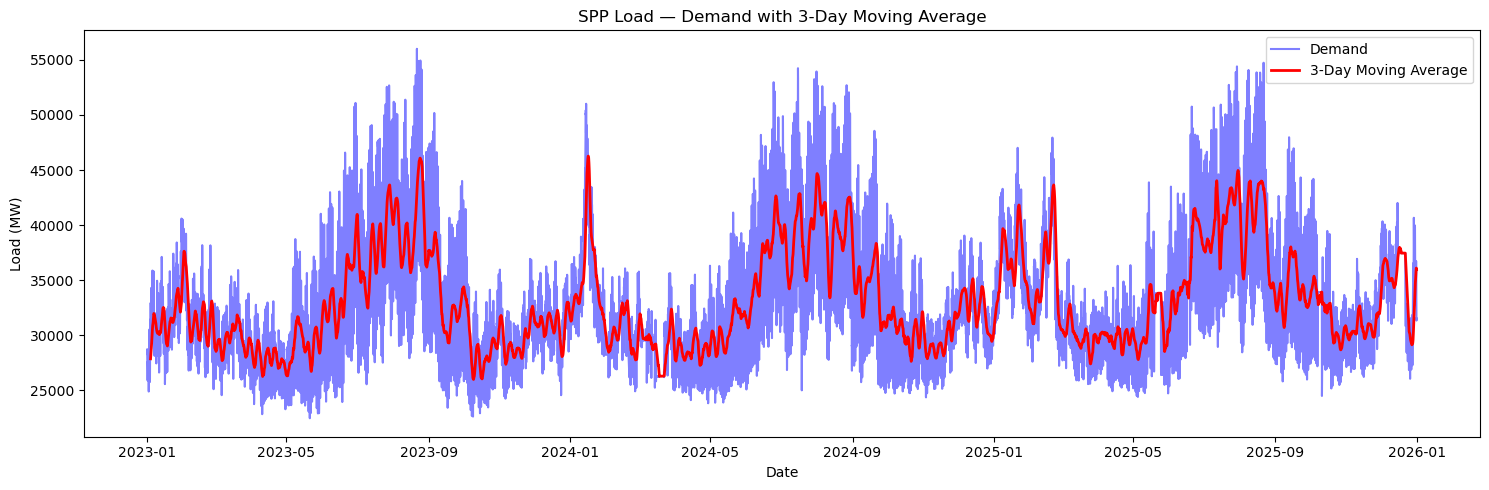

In [17]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(df.index, df["Demand"], label="Demand", color="blue", alpha=0.5)
ax.plot(df.index, df["Demand"].rolling(window=72).mean(), label="3-Day Moving Average", color="red", linewidth=2)

ax.set_title("SPP Load — Demand with 3-Day Moving Average")
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.legend()

plt.tight_layout()
plt.show()

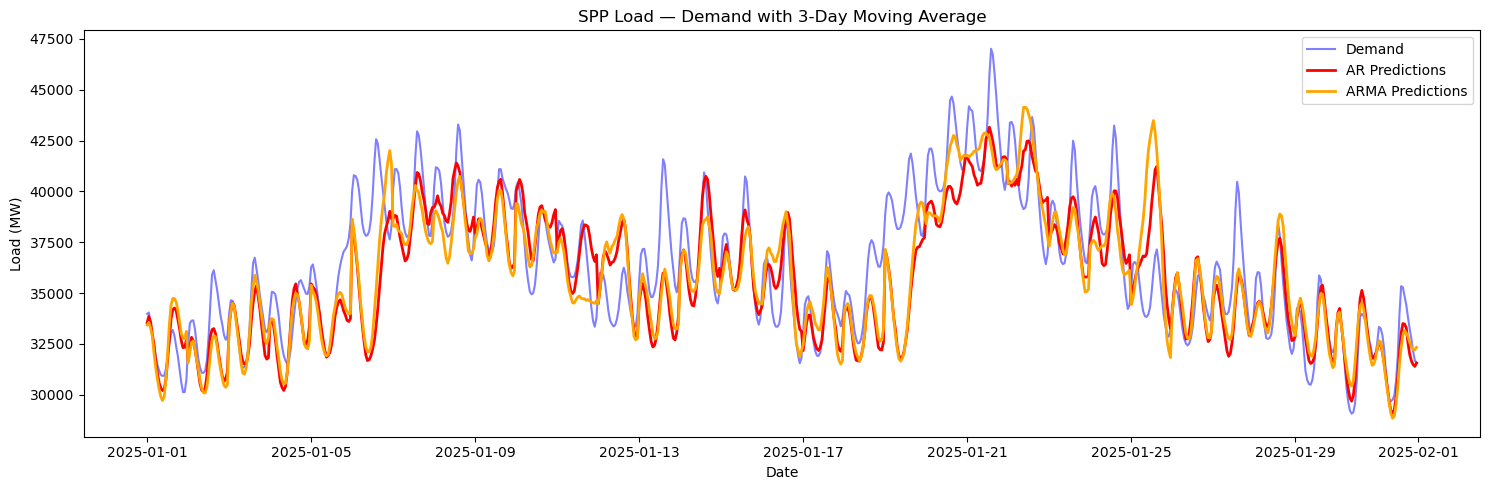

In [18]:
#graphic the actual values, the predicts from AR and ARMA
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(data_test.loc["2025-01"].index, data_test.loc["2025-01"]["Demand"], label="Demand", color="blue", alpha=0.5)
ax.plot(ar_predictions.loc["2025-01"].index, ar_predictions.loc["2025-01"]["pred"], label="AR Predictions", color="red", linewidth=2)
ax.plot(arma_predictions.loc["2025-01"].index, arma_predictions.loc["2025-01"]["pred"], label="ARMA Predictions", color="orange", linewidth=2)

ax.set_title("SPP Load — Demand with 3-Day Moving Average")
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.legend()

plt.tight_layout()
plt.show()

issue with big divergence with large increases/decreases in load. the prediction and actual are almost opposites of each other. This is a major flaw as large swings in load would be of greater importance when planning based on a forecast

### Exogenous Variables
- values of the exogenous variables must be known at the time of prediction.
- we will use temperature, daylight time, and calendar features

In [19]:
from features import set_holidays, cal_features, cyclic_features

In [20]:
data = df.copy()
data = (data
            .pipe(set_holidays)
            .pipe(cal_features)
            .pipe(cyclic_features)
            .assign(Holiday=lambda d: d["Holiday"].astype(int))
            .assign(Temp_3D_Mean=lambda d: d["Temperature"].rolling("3D", center = True).mean())
           )
# add a 1 day mean temperature mean?

In [21]:
# temp rolling 3 day average
#df["Temperature"].rolling(window=72).mean()
# is doing it by days too big of a window? mabye we add an expoential component to weight it?
#df.rolling("3D", center=True).mean() #mean(yesterday, today, tomorrow)

In [22]:
data.head()

,Demand,Temperature,is_day,Holiday,month,week,day_of_week,hour,month_sin,month_cos,week_sin,week_cos,day_sin,day_cos,hour_sin,hour_cos,Temp_3D_Mean
date,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,28291.0,11.3615,0,0,1,52,6,0,0.5,0.866025,0.0,1.0,-0.781831,0.62349,0.000000,1.000000,6.769608
2023-01-01 01:00:00,28727.0,9.5615,0,0,1,52,6,1,0.5,0.866025,0.0,1.0,-0.781831,0.62349,0.258819,0.965926,6.735184
2023-01-01 02:00:00,28370.0,7.9615,0,0,1,52,6,2,0.5,0.866025,0.0,1.0,-0.781831,0.62349,0.500000,0.866025,6.698679
2023-01-01 03:00:00,27955.0,7.3115,0,0,1,52,6,3,0.5,0.866025,0.0,1.0,-0.781831,0.62349,0.707107,0.707107,6.674000
2023-01-01 04:00:00,27668.0,6.2615,0,0,1,52,6,4,0.5,0.866025,0.0,1.0,-0.781831,0.62349,0.866025,0.500000,6.659061


In [23]:
exo_vars = list(data.columns)[1:]
exo_vars

['Temperature',
 'is_day',
 'Holiday',
 'month',
 'week',
 'day_of_week',
 'hour',
 'month_sin',
 'month_cos',
 'week_sin',
 'week_cos',
 'day_sin',
 'day_cos',
 'hour_sin',
 'hour_cos',
 'Temp_3D_Mean']

In [24]:
#resplit the data
data_train = data.loc[: TRAIN_END, :].copy()
data_val   = data.loc[VAL_START:VAL_END, :].copy()
data_test  = data.loc[TEST_START:, :].copy()

print(f"Train dates      : {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})")
print(f"Validation dates : {data_val.index.min()} --- {data_val.index.max()}  (n={len(data_val)})")
print(f"Test dates       : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})")

Train dates      : 2023-01-01 00:00:00 --- 2024-06-30 23:00:00  (n=13128)
Validation dates : 2024-07-01 00:00:00 --- 2024-12-31 23:00:00  (n=4416)
Test dates       : 2025-01-01 00:00:00 --- 2025-12-31 23:00:00  (n=8760)


In [25]:
# Add a three day moving average: Auto Regressive Moving Average model
#Create forecaster
window_features = RollingFeatures(stats=["mean"], window_sizes=24 * 3)
arma_forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = 24,
                 window_features = window_features
             )

In [26]:
# back test the model again with exogenous variables
# three day moving average forecaster
metric, predictions = backtesting_forecaster(
                          forecaster = arma_forecaster,
                          y          = data['Demand'],
                          exog       = data[exo_vars],
                          cv         = cv,
                          metric     = 'mean_absolute_error'
                      )
display(metric)
predictions.head()

100%|███████████████████████████████████████████████████████████| 365/365 [00:03<00:00, 112.11it/s]


,mean_absolute_error
0,1068.058624


,fold,pred
2025-01-01 00:00:00,0,34150.993148
2025-01-01 01:00:00,0,34605.156661
2025-01-01 02:00:00,0,34386.325001
2025-01-01 03:00:00,0,33937.799846
2025-01-01 04:00:00,0,33358.715591


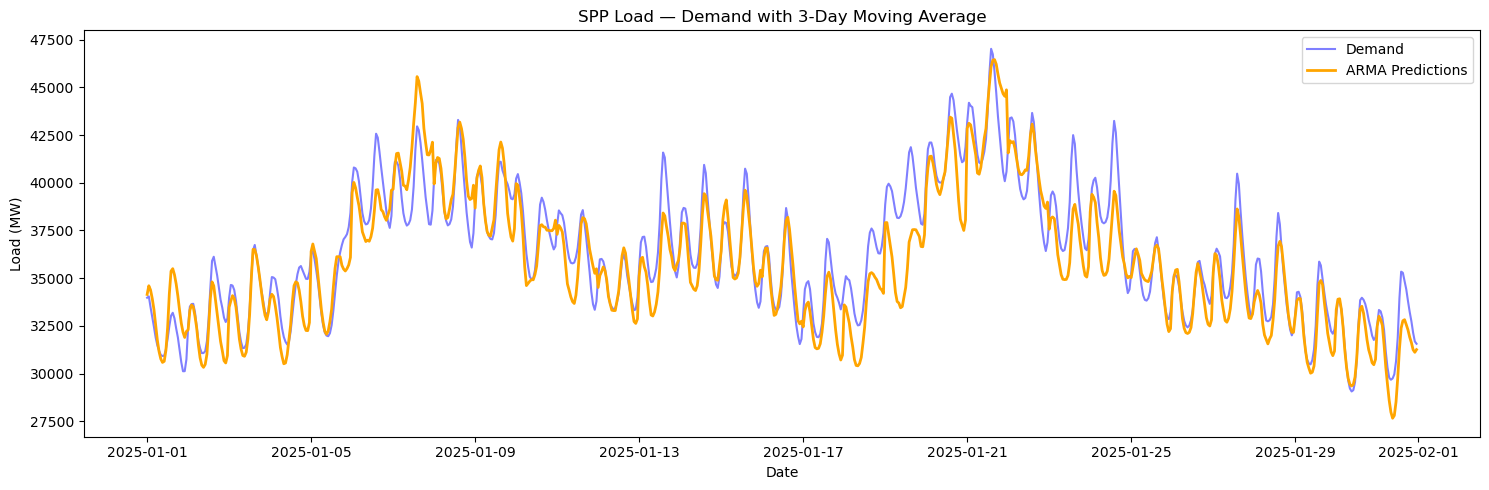

In [27]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(data_test.loc["2025-01"].index, data_test.loc["2025-01"]["Demand"], label="Demand", color="blue", alpha=0.5)
#ax.plot(predictions.loc["2025-01"].index, predictions.loc["2025-01"]["pred"], label="ARMA Predictions", color="red", linewidth=2)
ax.plot(predictions.loc["2025-01"].index, predictions.loc["2025-01"]["pred"], label="ARMA Predictions", color="orange", linewidth=2)

ax.set_title("SPP Load — Demand with 3-Day Moving Average")
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.legend()

plt.tight_layout()
plt.show()

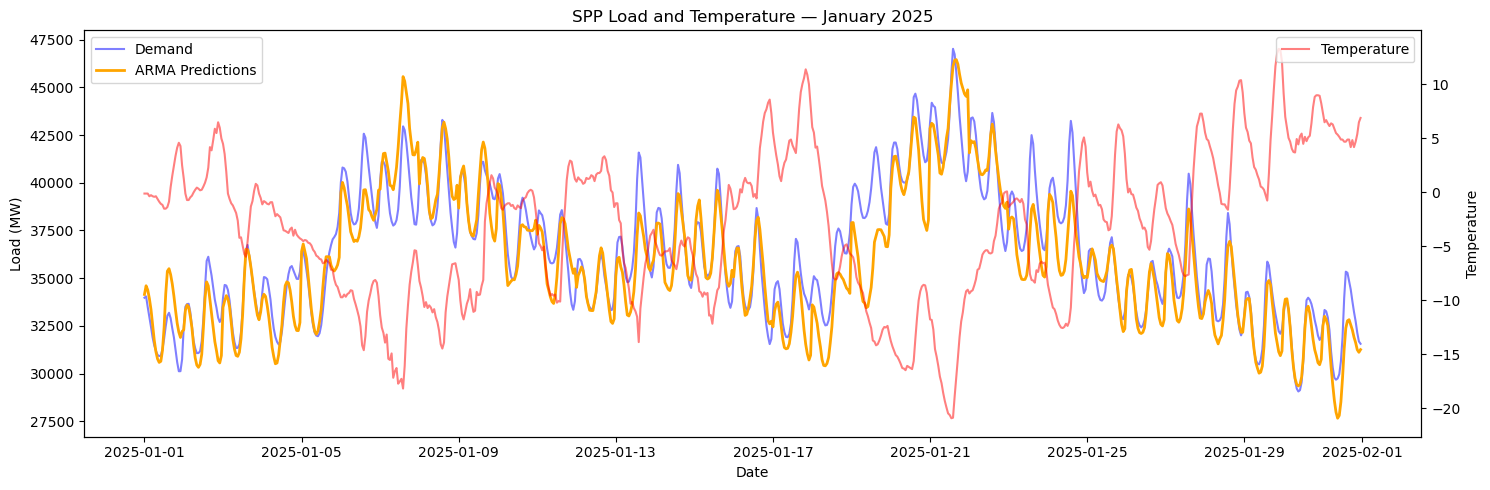

In [28]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(data_test.loc["2025-01"].index, data_test.loc["2025-01"]["Demand"], label="Demand", color="blue", alpha=0.5)
ax.plot(predictions.loc["2025-01"].index, predictions.loc["2025-01"]["pred"], label="ARMA Predictions", color="orange", linewidth=2)
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.legend(loc="upper left")

ax2 = ax.twinx()
ax2.plot(data_test.loc["2025-01"].index, data_test.loc["2025-01"]["Temperature"], label="Temperature", color="red", alpha=0.5)
ax2.set_ylabel("Temperature")
ax2.legend(loc="upper right")

plt.title("SPP Load and Temperature — January 2025")
plt.tight_layout()
plt.show()

visually the predictions are much loser to the actual demand, there is still a divergence around the 20th of january where the predictions move in the opposite direction of the acutal demand. this could be worth investigating more. 

In [36]:
#basic autoregressive
ar_forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = 24,
             )

In [37]:
metric, predictions = backtesting_forecaster(
                          forecaster = ar_forecaster,
                          y          = data['Demand'],
                          exog       = data[exo_vars],
                          cv         = cv,
                          metric     = 'mean_absolute_error'
                      )
display(metric)
predictions.head()

100%|███████████████████████████████████████████████████████████| 365/365 [00:01<00:00, 203.26it/s]


,mean_absolute_error
0,1080.09811


,fold,pred
2025-01-01 00:00:00,0,34128.965169
2025-01-01 01:00:00,0,34510.588456
2025-01-01 02:00:00,0,34323.328227
2025-01-01 03:00:00,0,33957.696435
2025-01-01 04:00:00,0,33292.283361


### Feature Importance before selection process
- we can use the feature importance feature of the forecaster to get a feel of which features should be selected
- pair this with domian knowledge should give us an inituitve idea of what features we would expect feature selection to select

In [41]:
ar_forecaster.fit(y=data.loc[:VAL_END, 'Demand'], exog =data.loc[:VAL_END, exo_vars])

In [42]:
ar_forecaster.get_feature_importances(sort_importance=True)

,feature,importance
0,lag_1,626
37,hour_sin,206
24,Temperature,181
30,hour,177
23,lag_24,166
29,day_of_week,133
39,Temp_3D_Mean,111
2,lag_3,108
20,lag_21,103
38,hour_cos,98


- the exogenous variables reduce the error of the model and it makes the model with moving average out perform the basic auto regressive model. possible extensions of exogenous variables could include different window sizes of mean weather and creating polynomial features form the exogenous variables to capture inreaction
- interesting that the month feautres are some of the least important feautres

In [43]:
#create a model with week long lags
ar_week_forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = 192,
             )

In [44]:
ar_week_forecaster.fit(y=data.loc[:VAL_END, 'Demand'], exog =data.loc[:VAL_END, exo_vars])

In [54]:
ar_week_forecaster.get_feature_importances(sort_importance=True).head(40)

,feature,importance
0,lag_1,526
192,Temperature,151
205,hour_sin,138
198,hour,99
21,lag_22,82
197,day_of_week,73
25,lag_26,73
207,Temp_3D_Mean,72
206,hour_cos,71
20,lag_21,66


<Axes: >

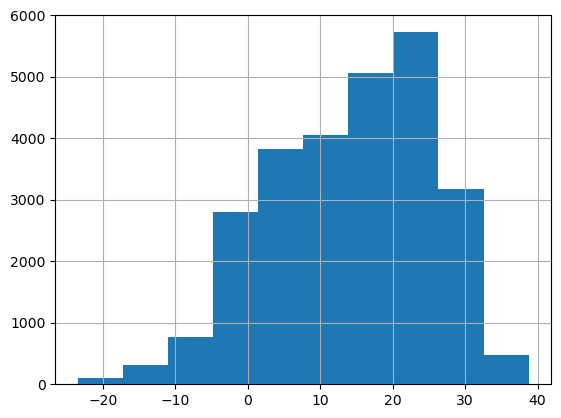

In [53]:
data.Temperature.hist()

### Feature Selection
- will use a simple model to find the best features and then retrain with more complex model
- will also use a smaller subset of the data to select features than the modeling training step

In [31]:
#lags to tests
test_lags = [1, 2, 3, 23, 24, 25, 47, 48, 49]

In [32]:
#create estimator(solver) and the forecaster (matrix formulation)
estimator = LGBMRegressor(
                n_estimators = 100,
                max_depth    = 4,
                random_state = 15926,
                verbose      = -1
            )

forecaster = ForecasterRecursive(
                 estimator       = estimator,
                 lags            = test_lags,
                 window_features = window_features
             )

In [33]:
# Recursive feature elimination with cross-validation
# doing cv and a subsample might have introduced noise that elimated the Holiday feature
# by domain knowledge holiday and a 24 hour lag should likely be in the model
# issue could be with feature selection setup
warnings.filterwarnings("ignore", message="X does not have valid feature names.*")
selector = RFECV(
    estimator = estimator,
    step      = 1,
    cv        = 3,
)
lags_select, window_features_select, exog_select = select_features(
    forecaster      = forecaster,
    selector        = selector,
    y               = data_train['Demand'],
    exog            = data_train[exo_vars],
    select_only     = None,
    force_inclusion = None,
    subsample       = 0.5,  # Subsample to speed up the process
    random_state    = 123,
    verbose         = True,
)

Recursive feature elimination (RFECV)
-------------------------------------
Total number of records available: 13056
Total number of records used for feature selection: 6528
Number of features available: 26
    Lags            (n=9)
    Window features (n=1)
    Exog            (n=16)
Number of features selected: 13
    Lags            (n=6) : [1, 2, 3, 23, 25, 47]
    Window features (n=0) : []
    Exog            (n=7) : ['Temperature', 'week', 'day_of_week', 'hour', 'hour_sin', 'hour_cos', 'Temp_3D_Mean']


In [34]:
#retrain the model and cross validate
# Create a forecaster with the selected features
forecaster = ForecasterRecursive(
                estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                lags            = lags_select,
             )
# Backtesting model with exogenous variables on test data
metric, predictions = backtesting_forecaster(
                            forecaster = forecaster,
                            y          = data['Demand'],
                            exog       = data[exog_select],
                            cv         = cv,
                            metric     = 'mean_absolute_error'
                      )                
metric

100%|███████████████████████████████████████████████████████████| 365/365 [00:01<00:00, 199.72it/s]


,mean_absolute_error
0,1162.60299


In [35]:
#pull the feature importance of a fitted model before feature selection
forecaster.get_feature_importances(sort_importance=True)

NotFittedError: This forecaster is not fitted yet. Call `fit` with appropriate arguments before using `get_feature_importances()`.

the error did increase when using only the selected features but it is not a huge increase. Maybe we need to add a wider variety of features to test

### Hyper Parameter Tuning